In [1]:
import pandas as pd
import numpy as np
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
# Read in dataframe
cells = pd.read_csv('../data/cd34_clustering_results_patient_updated.csv', index_col=0)
cells.columns = cells.columns.str.replace('Unnamed: 0', 'FileName')

# Delete spare progression sample (there was a second later measurement which was associated with progression)
cells = cells.loc[cells['FileName'] != 'P02_SPD',:]
cells = cells.loc[~cells['FileName'].str.contains('P26'),:]
cells = cells.loc[~cells['FileName'].str.contains('P27'),:]
cells = cells.loc[~cells['FileName'].str.contains('P15'),:]
cells['FileName'] = cells['FileName'].str.replace('P02_SPD_2', 'P02_SPD')
cells.head()
cells.head()

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,FlowSOM_metacluster_11,FlowSOM_metacluster_12,FlowSOM_metacluster_13,FlowSOM_metacluster_14,FlowSOM_metacluster_15,FlowSOM_metacluster_16,FlowSOM_metacluster_17,FlowSOM_metacluster_18,FlowSOM_metacluster_19,FlowSOM_metacluster_20
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,3148,168,1015,15,29,1225,720,54,0,183
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,535,86,169,0,1,343,118,10,0,21
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,60,66,24,2,1,50,14,15,0,3
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,61,67,12,0,0,26,2,6,0,2
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,2351,222,34,4,11,13,28,32,19,7


In [3]:
cells.head()

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,FlowSOM_metacluster_11,FlowSOM_metacluster_12,FlowSOM_metacluster_13,FlowSOM_metacluster_14,FlowSOM_metacluster_15,FlowSOM_metacluster_16,FlowSOM_metacluster_17,FlowSOM_metacluster_18,FlowSOM_metacluster_19,FlowSOM_metacluster_20
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,3148,168,1015,15,29,1225,720,54,0,183
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,535,86,169,0,1,343,118,10,0,21
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,60,66,24,2,1,50,14,15,0,3
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,61,67,12,0,0,26,2,6,0,2
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,2351,222,34,4,11,13,28,32,19,7


In [4]:
# Read in patient outcomes
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes_diagnosis_dict = dict(zip(outcomes['PID'], outcomes['Diagnosis']))
outcomes_c6_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_c12_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))

In [5]:
# Map the filenames back to some clinical information
pid = {}
timepoint = {}
out_6 = {}
out_12 = {}
for i in cells['FileName']:
    if i.startswith('P'):
        x = i.split('_')[0]
        y = '_'.join(i.split('_')[1:])
        pid[i] = x
        timepoint[i] = y
        out_6[i] = outcomes_c6_dict[x]
        out_12[i] = outcomes_c12_dict[x]
    else:
        pid[i] = i
        timepoint[i] = 'Control'
        out_6[i] = 'Control'
        out_12[i] = 'Control'

cells['pid'] = cells['FileName'].map(pid)
cells['timepoint'] = cells['FileName'].map(timepoint)
cells['out_6'] =  cells['FileName'].map(out_6)
cells['out_12'] = cells['FileName'].map(out_12)

In [6]:
# Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FileName'].str.contains('P27'),:]
cells = cells.loc[~cells['FileName'].str.contains('P15'),:]
print(cells.shape)

(109, 25)


In [7]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows=40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the 
# dataframe such as diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))
outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))
outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))

In [8]:
cells

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,FlowSOM_metacluster_15,FlowSOM_metacluster_16,FlowSOM_metacluster_17,FlowSOM_metacluster_18,FlowSOM_metacluster_19,FlowSOM_metacluster_20,pid,timepoint,out_6,out_12
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,29,1225,720,54,0,183,P08,C1_D8,non-responder_2,non-responder_2
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,1,343,118,10,0,21,P08,C7_D1,non-responder_2,non-responder_2
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,1,50,14,15,0,3,P08,C7_D22,non-responder_2,non-responder_2
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,0,26,2,6,0,2,P08,SPD,non-responder_2,non-responder_2
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,11,13,28,32,19,7,P24,C1_D1,non-responder_2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,Control_5,15,14,152,43,1,0,0,18,1,...,1,0,43,0,0,2,Control_5,Control,Control,Control
110,Control_16,31,94,352,299,2,55,2,454,26,...,142,36,578,1,1,66,Control_16,Control,Control,Control
111,Control_10,0,4,47,8,0,1,0,583,0,...,0,21,52,1,0,1,Control_10,Control,Control,Control
112,Control_4,9,7,89,26,0,1,0,28,0,...,2,1,38,0,1,1,Control_4,Control,Control,Control


In [9]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['pid'].map(diagnosis_dx)
cells['outcome_6'] = cells['pid'].map(outcome_C6_dx)
cells['outcome_12'] = cells['pid'].map(outcome_C12_dx)

pid_timepoint = [x + '_' + y if 'P' in x else x 
                 for x, y in zip(cells['pid'], cells['timepoint'])]

cells['pid_timepoint'] = pid_timepoint
cells['pid_timepoint'] = cells['pid_timepoint'].astype(str)

In [10]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cells1 = pd.merge(cells, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')

# Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cells['pid'], cells['diagnosis'])]  

outcome_6 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cells['pid'], cells['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cells['pid'], cells['outcome_12'])]
      
cells1['diagnosis'] = diagnosis
cells1['outcome_6'] = outcome_6
cells1['outcome_12'] = outcome_12
cells1['PID_Timepoint'] = cells1['pid'] + cells1['timepoint']

In [11]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1D1': 1, 'C1D8': 8, 'C7D1': 168, 'C7D22': 190, 'C12D29': 336,
    'Progression': 275,  'Healthy': 0.4}
    
cells1['time'] = cells1['timepoint'].map(time)
cells1

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,out_12,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C1_D8,NaN,NaN,NaN,P08C1_D8,NaN
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D1,NaN,NaN,NaN,P08C7_D1,NaN
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D22,NaN,NaN,NaN,P08C7_D22,NaN
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,NaN,NaN,P08SPD,NaN
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,NaN,AML,non-responder_2,NaN,P24_C1_D1,NaN,NaN,NaN,P24C1_D1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,Control_5,15,14,152,43,1,0,0,18,1,...,Control,NaN,NaN,NaN,Control_5,NaN,NaN,NaN,Control_5Control,NaN
105,Control_16,31,94,352,299,2,55,2,454,26,...,Control,NaN,NaN,NaN,Control_16,NaN,NaN,NaN,Control_16Control,NaN
106,Control_10,0,4,47,8,0,1,0,583,0,...,Control,NaN,NaN,NaN,Control_10,NaN,NaN,NaN,Control_10Control,NaN
107,Control_4,9,7,89,26,0,1,0,28,0,...,Control,NaN,NaN,NaN,Control_4,NaN,NaN,NaN,Control_4Control,NaN


In [12]:
# Read in the clustering results
cluster_result = pd.read_csv('../data/cd34_annotation.csv')
cell_type_dict = dict(zip(cluster_result['cluster'], cluster_result['cell_type'].str.replace(' ', '_')))
cell_type_dict

{1: 'CD33_HSC',
 2: 'Myeloid_precursor',
 3: 'HSC',
 4: 'Myeloid_precursor',
 5: 'Myeloid_precursor',
 6: 'CD56_pos',
 7: 'CD56_pos',
 8: 'Myeloid_precursor',
 9: 'Myeloid_precursor',
 10: 'Myeloid_precursor',
 11: 'MEP',
 12: 'GMP',
 13: 'GMP',
 14: 'Myeloid_precursor',
 15: 'CD56_pos',
 16: 'CMP',
 17: 'Myeloid_precursor',
 18: 'MEP',
 19: 'Myeloid_precursor',
 20: 'Myeloid_precursor'}

In [13]:
# Create a dictionary which relates each cell annotation to a 
# flowsom cluster
cell_dict = {}
for key, value in cell_type_dict.items():
    if value in cell_dict:
        cell_dict[value].append(str(key))
    else:
        cell_dict[value] = [str(key)]
cell_dict

{'CD33_HSC': ['1'],
 'Myeloid_precursor': ['2', '4', '5', '8', '9', '10', '14', '17', '19', '20'],
 'HSC': ['3'],
 'CD56_pos': ['6', '7', '15'],
 'MEP': ['11', '18'],
 'GMP': ['12', '13'],
 'CMP': ['16']}

In [14]:
# Replace the string in the column names so that we can sum the desired columns
cells1.columns = cells1.columns.str.replace('FlowSOM_metacluster_', '')
cells1.head()

,FileName,1,2,3,4,5,6,7,8,9,...,out_12,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C1_D8,NaN,NaN,NaN,P08C1_D8,NaN
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D1,NaN,NaN,NaN,P08C7_D1,NaN
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D22,NaN,NaN,NaN,P08C7_D22,NaN
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,non-responder_2,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,NaN,NaN,P08SPD,NaN
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,NaN,AML,non-responder_2,NaN,P24_C1_D1,NaN,NaN,NaN,P24C1_D1,NaN


In [15]:
# Sum together the columns which belong to specific cell types and delete the leftover columns
for new_col, cols_to_sum in cell_dict.items():
    cells1[new_col] = cells1[cols_to_sum].sum(axis=1)

# Drop columns with numerical names
cols = [str(i + 1) for i in range(20)]
cells1.drop(columns=cols, inplace=True)

del cols
cells1.head()

,FileName,pid,timepoint,out_6,out_12,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,...,Day_since_scr,PID_Timepoint,time,CD33_HSC,Myeloid_precursor,HSC,CD56_pos,MEP,GMP,CMP
0,P08_C1_D8,P08,C1_D8,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C1_D8,NaN,...,NaN,P08C1_D8,NaN,309,4092,630,60,3202,1183,1225
1,P08_C7_D1,P08,C7_D1,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D1,NaN,...,NaN,P08C7_D1,NaN,184,1050,159,9,545,255,343
2,P08_C7_D22,P08,C7_D22,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D22,NaN,...,NaN,P08C7_D22,NaN,75,152,36,1,75,90,50
3,P08_SPD,P08,SPD,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,...,NaN,P08SPD,NaN,76,93,46,0,67,79,26
4,P24_C1_D1,P24,C1_D1,non-responder_2,NaN,AML,non-responder_2,NaN,P24_C1_D1,NaN,...,NaN,P24C1_D1,NaN,2084,2981,11708,42,2383,256,13


In [16]:
# Create a column which details the percentage of CD34 cells
cells1['total_cd34'] = cells1.loc[:, 'CD33_HSC':].sum(axis=1)
cells1.to_csv('hspc_progenitor_cell_numbers.csv', sep = ',')

In [17]:
# Read in a dataframe which details the number of myeloid cells 
# so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/patient_metacluster_table_patient_updated.csv', index_col=0)
# cells = cells.drop(cells.loc[:, 'FlowSOM_metacluster_1': 'FlowSOM_metacluster_20'], axis = 1)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1' :'metacluster_9'].sum(axis = 1)

total_dict = dict(zip(hspc['FileNames'].str.replace('_Myeloid_Panel', ''),  hspc['total_cells']))

cells1['total_cells']= cells1['FileName'].map(total_dict)

del total_dict

In [18]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column

time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']

to_del = [x for x, y in zip(cells1['pid_timepoint'], cells1['outcome_12']) 
          if 'C7_D22' in x and y not in time_to_keep]
to_del
print(cells1.shape)
cells1 = cells1.loc[~cells1['pid_timepoint'].isin(to_del), :]
print(cells1.shape)

del to_del

(109, 23)
(107, 23)


In [19]:
cells1

,FileName,pid,timepoint,out_6,out_12,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,...,time,CD33_HSC,Myeloid_precursor,HSC,CD56_pos,MEP,GMP,CMP,total_cd34,total_cells
0,P08_C1_D8,P08,C1_D8,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C1_D8,NaN,...,NaN,309,4092,630,60,3202,1183,1225,10701,131736.0
1,P08_C7_D1,P08,C7_D1,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D1,NaN,...,NaN,184,1050,159,9,545,255,343,2545,21025.0
2,P08_C7_D22,P08,C7_D22,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D22,NaN,...,NaN,75,152,36,1,75,90,50,479,11346.0
3,P08_SPD,P08,SPD,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,...,NaN,76,93,46,0,67,79,26,387,7687.0
4,P24_C1_D1,P24,C1_D1,non-responder_2,NaN,AML,non-responder_2,NaN,P24_C1_D1,NaN,...,NaN,2084,2981,11708,42,2383,256,13,19467,56727.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,Control_5,Control_5,Control,Control,Control,NaN,NaN,NaN,Control_5,NaN,...,NaN,15,418,152,1,162,16,0,764,143798.0
105,Control_16,Control_16,Control,Control,Control,NaN,NaN,NaN,Control_16,NaN,...,NaN,31,1569,352,199,1905,240,36,4332,68549.0
106,Control_10,Control_10,Control,Control,Control,NaN,NaN,NaN,Control_10,NaN,...,NaN,0,1826,47,1,125,106,21,2126,131440.0
107,Control_4,Control_4,Control,Control,Control,NaN,NaN,NaN,Control_4,NaN,...,NaN,9,214,89,3,75,9,1,400,74840.0


In [20]:
# Add a column called best response which details the best clinical 
# response of each patient .If a patient is called a responder at 
# any timepont they are called a responder even if they eventually progress
best_response = []
for x, y, z in zip(cells1['outcome_6'], cells1['outcome_12'], cells1['FileName']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder')
    elif 'Control' in z:
        best_response.append('Control')
    else:
        best_response.append('non-responder')

cells1['best_response'] = best_response

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_60267/1106793346.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells1['best_response'] = best_response


In [21]:
# Create dataframes with the percentage of cells as a percent of CD34 
# or a percentage of CD45
cells3 = cells1.copy()
cells4 = cells1.copy()
cells3.loc[:, 'CD33_HSC':'CMP'] = cells3.loc[:, 'CD33_HSC':'CMP'].divide(cells3.loc[:,'total_cells'], axis = 'rows') * 100
cells4.loc[:, 'CD33_HSC':'CMP'] = cells4.loc[:, 'CD33_HSC':'CMP'].divide(cells4.loc[:,'total_cd34'], axis = 'rows') * 100

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_60267/2614000857.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2.34560029e-01 8.75148633e-01 6.61025912e-01 9.88682191e-01
 3.67373561e+00 7.28295756e-01 3.47839565e+00 1.21978869e-01
 2.63188814e-02 1.59782696e-01 7.69962575e-02 4.11220846e-03
 2.86284810e-02 1.36247344e-02 2.03186932e-01 1.94295485e-02
 1.87778734e-01 3.72142065e-02 3.90780193e-03 9.85682994e-01
 4.62371676e+00 1.78339397e+00 1.02358049e+00 1.02235463e+00
 5.83432162e-01 1.50674611e+00 6.44705738e-02 4.33043788e-02
 6.68604651e-01 2.63084243e-01 5.58602435e-01 6.47602227e-01
 2.05377969e-02 4.48231256e-02 5.67140738e-02 2.93786881e-02
 2.15256434e+00 1.24569101e+00 1.70168571e+00 3.14385380e+00
 4.21402354e-02 1.09721825e-01 1.47109302e-02 1.51106858e-02
 1.81023445e-01 1.53011545e-01 1.89181718e+01 0.00000000e+00
 6.99463744e-02 1.14852005e-01 5.80593657e-02 5.72803299e-02
 1.9242

In [22]:
# Read in p-values file
pval = pd.read_excel('../data/2024_11_12_pvalues_from_jake.xlsx')
pval

,Cell_type,p_value
0,CD33_HSC,0.76020
1,CD56_pos,0.55450
2,CMP,0.22215
3,GMP,0.04050
4,HSC,0.90750
5,MEP,0.84380
6,Myeloid_precursor,0.50060


In [23]:
cells3

,FileName,pid,timepoint,out_6,out_12,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,...,CD33_HSC,Myeloid_precursor,HSC,CD56_pos,MEP,GMP,CMP,total_cd34,total_cells,best_response
0,P08_C1_D8,P08,C1_D8,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C1_D8,NaN,...,0.234560,3.106212,0.478229,0.045546,2.430619,0.898008,0.929890,10701,131736.0,non-responder
1,P08_C7_D1,P08,C7_D1,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D1,NaN,...,0.875149,4.994055,0.756243,0.042806,2.592152,1.212842,1.631391,2545,21025.0,non-responder
2,P08_C7_D22,P08,C7_D22,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_C7_D22,NaN,...,0.661026,1.339679,0.317292,0.008814,0.661026,0.793231,0.440684,479,11346.0,non-responder
3,P08_SPD,P08,SPD,non-responder_2,non-responder_2,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,...,0.988682,1.209835,0.598413,0.000000,0.871601,1.027709,0.338233,387,7687.0,non-responder
4,P24_C1_D1,P24,C1_D1,non-responder_2,NaN,AML,non-responder_2,NaN,P24_C1_D1,NaN,...,3.673736,5.254993,20.639202,0.074039,4.200821,0.451284,0.022917,19467,56727.0,non-responder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,Control_5,Control_5,Control,Control,Control,NaN,NaN,NaN,Control_5,NaN,...,0.010431,0.290686,0.105704,0.000695,0.112658,0.011127,0.000000,764,143798.0,Control
105,Control_16,Control_16,Control,Control,Control,NaN,NaN,NaN,Control_16,NaN,...,0.045223,2.288874,0.513501,0.290303,2.779034,0.350115,0.052517,4332,68549.0,Control
106,Control_10,Control_10,Control,Control,Control,NaN,NaN,NaN,Control_10,NaN,...,0.000000,1.389227,0.035758,0.000761,0.095100,0.080645,0.015977,2126,131440.0,Control
107,Control_4,Control_4,Control,Control,Control,NaN,NaN,NaN,Control_4,NaN,...,0.012026,0.285943,0.118920,0.004009,0.100214,0.012026,0.001336,400,74840.0,Control


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_60267/3617809021.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells3['time2'] = timejitter
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single eleme

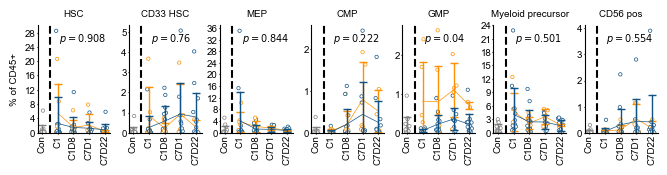

In [24]:
import warnings
from matplotlib.patheffects import Normal

plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'

figure_list = ['HSC', 'CD33_HSC', 'MEP', 'CMP', 'GMP', 'Myeloid_precursor', 'CD56_pos']
timepoint_dict = {'C1_D1': 2, 'C1_D8': 3, 'C7_D1': 4, 'C7_D22': 5, 'C12_D29': 6, 'Progression': 7, 'Control': 1}
cells3['time1'] = cells3['timepoint'].map(timepoint_dict)
color_dict = {'non-responder': '#fe9003', 'responder': '#115284', 'Control': 'grey'}

cells3 = cells3.loc[cells3['timepoint'] != 'C12_D29', :]

# Populate stars before jitter loop
cells_of_total1 = cells3.loc[cells3['timepoint'] == 'Progression', :]
stars = cells_of_total1['pid'].to_list()


# Create states
x_jitter = np.random.normal(0, 0.75, size=cells3.shape[0])
timejitter = []
for z, (x, y) in enumerate(zip(cells3['time1'], x_jitter)):
    if z % 2 == 0:
        timejitter.append(x + (y / 10))
    else:
        timejitter.append(x - (y / 10))

cells3['time2'] = timejitter

stars1 = cells3.loc[(cells3['timepoint'].isin(stars)) & (cells3['timepoint'] == 'C7D22'), :].reset_index(drop=True)


# FIX: reset_index to avoid seaborn/pandas Series alignment warnings
cells_of_total = cells3.loc[cells3['timepoint'] != 'Progression', :].reset_index(drop=True)

fig, axs = plt.subplots(1, 7, figsize=(8, 1.4))
fig.subplots_adjust(hspace=0.1, wspace=0.25)
axs_flatten = axs.flatten()

for x, ax in enumerate(axs_flatten):

    # Plot all points
    ax.scatter(x=cells_of_total['time2'].values,
               y=cells_of_total[figure_list[x]].values,
               color='white',
               edgecolors=cells_of_total['best_response'].map(color_dict).values,
               s=6, lw=0.5)

    # Plot a linegraph
    sns.lineplot(data=cells_of_total, x='time1', y=figure_list[x],
                 err_style='bars', errorbar='sd',
                 err_kws={'linewidth': 1, 'capsize': 3, 'capthick': 1},
                 legend=False, hue='best_response', palette=color_dict,
                 linewidth=0.5, ax=ax)

    # Plot a scatterplot which indicates which patients progressed
    ax.scatter(x=stars1['time2'].values,
               y=stars1[figure_list[x]].values,
               s=6, color='white', edgecolors='hotpink', lw=0.5)

    ax.axvline(1.5, color='black', ls='--')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['Con', 'C1', 'C1D8', 'C7D1', 'C7D22'], rotation=90, fontsize=7)
    
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=7, pad=0.5, length=1)
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylim(bottom=0)

    e = figure_list[x].replace('_', ' ').replace('Cells', 'Cell')
    ax.set_title(e, fontsize=7)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_pos = xmin + 0.3 * (xmax - xmin)
    y_pos = ymax - 0.15 * (ymax - ymin)

    text = round(pval.loc[pval['Cell_type'] == figure_list[x], 'p_value'].iloc[0], 3)
    ax.text(s=f'$\\it{{p}} = {text}$', x=x_pos, y=y_pos, fontsize=7)
    ax.set_xlabel('', fontsize=9)
    if x == 0:
        ax.set_ylabel('% of CD45+', fontsize=7)
    else:
        ax.set_ylabel('')
    

#plt.savefig('results/figure_2_second_part.pdf', dpi=600)